In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

       

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
import cv2
import matplotlib.pyplot as plt
import os

images_dir = r'/kaggle/input/arabic-sign-language-dataset-2022/datasets/train/images'
labels_dir = r'/kaggle/input/arabic-sign-language-dataset-2022/datasets/train/labels'

pairs=[]

for labl in os.listdir(labels_dir) :
    if labl.endswith(".txt"):
        image_file = labl.replace(".txt", ".jpg")
    image_path= os.path.join(images_dir,image_file)
    label_path= os.path.join(labels_dir,labl)
    if os.path.exists(image_path):        
        pairs.append((image_path,label_path))

In [6]:
print("Found pairs:")
print(len(pairs))

Found pairs:
9955


In [7]:
import cv2
import os

def load_and_split(image_path, label_path):
    image = cv2.imread(image_path)
    H, W, _ = image.shape

    with open(label_path, "r") as f:
        line = f.readline().strip().split()
        class_id = int(line[0])
        x_center = float(line[1])
        y_center = float(line[2])
        w = float(line[3])
        h = float(line[4])

    # Convert normalized to pixel values
    x_center *= W
    y_center *= H
    box_w = w * W
    box_h = h * H

    x1 = int(x_center - box_w / 2)
    y1 = int(y_center - box_h / 2)
    x2 = int(x_center + box_w / 2)
    y2 = int(y_center + box_h / 2)

    crop = image[y1:y2, x1:x2]

    # return crop, id, and maybe filename
    return crop, class_id, os.path.basename(image_path)

In [8]:
import numpy as np

X, y, names = [], [], []

for img_path, lbl_path in pairs:
    crop, class_id, filename = load_and_split(img_path, lbl_path)
    crop = cv2.resize(crop, (64, 64))
    X.append(crop)
    y.append(class_id)
    names.append(filename) 

X = np.array(X, dtype="float32") / 255.0
y = np.array(y)


In [9]:
print(X.shape)
num_classes = len(np.unique(y))
print("Number of classes:", num_classes)
print("Classes:", np.unique(y))

(9955, 64, 64, 3)
Number of classes: 32
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]


In [10]:
from tensorflow.keras.utils import to_categorical

y_cat = to_categorical(y, num_classes=32)
print(y_cat.shape)

2025-09-12 17:36:47.905550: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757698608.307190      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757698608.418629      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


(9955, 32)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define CNN
model = models.Sequential([
    # Convolutional block 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),

    # Convolutional block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten + Dense
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(32, activation='softmax')  # 32 classes
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,            # stop if val_loss doesn’t improve for 5 epochs
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,            # reduce LR by half
    patience=3,            # wait 3 epochs before reducing
    min_lr=1e-6
)
from sklearn.model_selection import train_test_split

# Split into train (70%), validation (15%), test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1757698627.416019      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1757698627.416712      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Train shape: (6968, 64, 64, 3) (6968,)
Val shape: (1493, 64, 64, 3) (1493,)
Test shape: (1494, 64, 64, 3) (1494,)


In [13]:
# Training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

# Final evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/30


I0000 00:00:1757698632.474819     100 service.cc:148] XLA service 0x7a8fe40058d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757698632.476072     100 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1757698632.476093     100 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1757698632.837650     100 cuda_dnn.cc:529] Loaded cuDNN version 90300


 30/218 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0360 - loss: 3.4893

I0000 00:00:1757698636.744847     100 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


218/218 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.0392 - loss: 3.4615 - val_accuracy: 0.1286 - val_loss: 3.0563 - learning_rate: 0.0010
Epoch 2/30
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1490 - loss: 2.9769 - val_accuracy: 0.3570 - val_loss: 2.3330 - learning_rate: 0.0010
Epoch 3/30
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2661 - loss: 2.4229 - val_accuracy: 0.4910 - val_loss: 1.7394 - learning_rate: 0.0010
Epoch 4/30
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3899 - loss: 2.0113 - val_accuracy: 0.5727 - val_loss: 1.5295 - learning_rate: 0.0010
Epoch 5/30
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4545 - loss: 1.7271 - val_accuracy: 0.6142 - val_loss: 1.2836 - learning_rate: 0.0010
Epoch 6/30
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5047 - loss: 1.5576 - val_accuracy: 0.6530 - val_loss: 1.1431 - learning_rate: 0.0010
Epoch 7/30
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5579 - loss: 1.4239 - val_accur

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


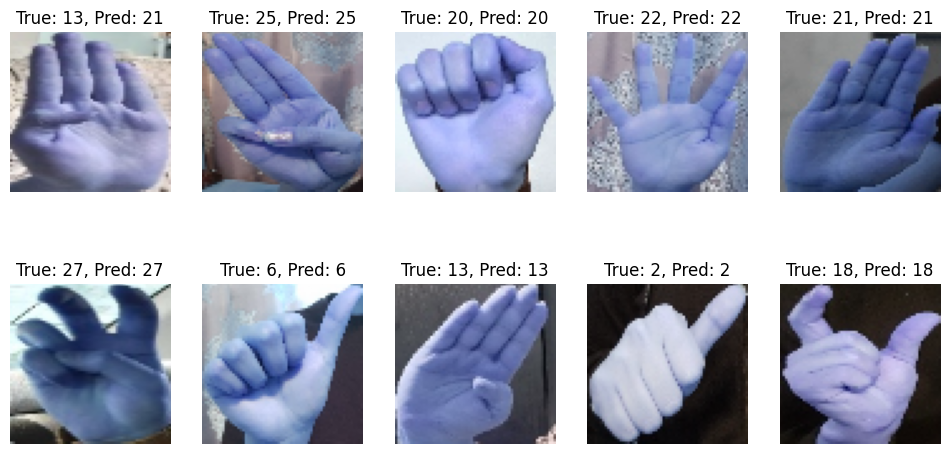

In [14]:
# y_test is already integer labels
y_true = y_test  

# Get predicted class IDs
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Show random samples with predictions
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
for i in range(10):
    idx = np.random.randint(0, len(X_test))
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx])
    plt.axis("off")
    plt.title(f"True: {y_true[idx]}, Pred: {y_pred[idx]}")
plt.show()


In [15]:
id2label = {
    0: "ain",
    1: "al",
    2: "aleff",
    3: "bb",
    4: "dal",
    5: "dha",
    6: "dhad",
    7: "fa",
    8: "Qaaf",
    9: "Ghain",
    10: "Ha",
    11: "Haa",
    12: "Jeem",
    13: "kaf",
    14: "khaa",
    15: "la",
    16: "laam",
    17: "meem",
    18: "nun",
    19: "ra",
    20: "saad",
    21: "seen",
    22: "sheen",
    23: "ta",
    24: "taa",
    25: "thaa",
    26: "thal",
    27: "toot",
    28: "waw",
    29: "ya",
    30: "yaa",
    31: "zay"
}


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


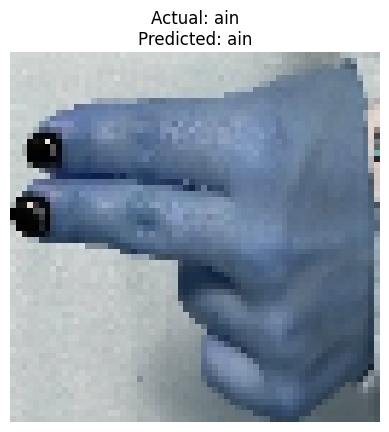

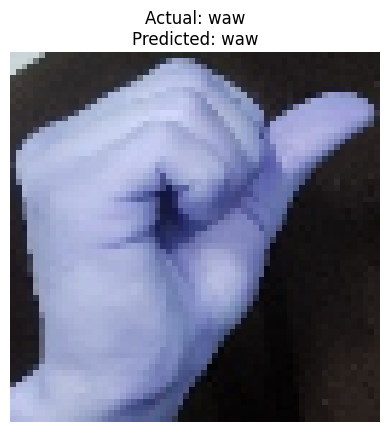

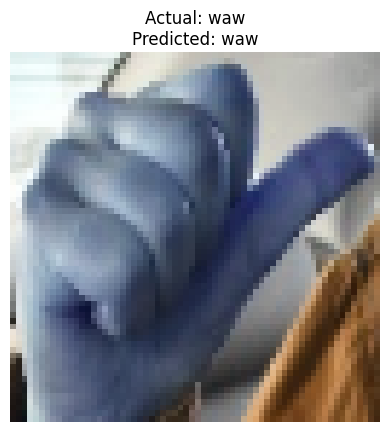

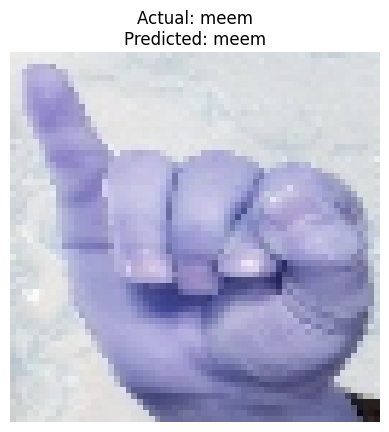

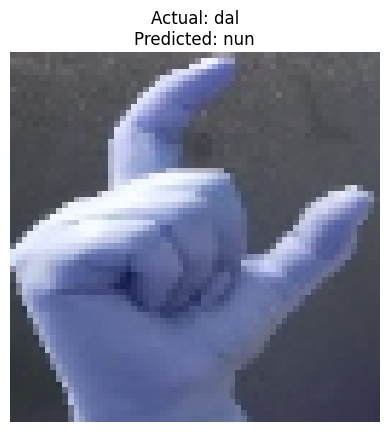

In [17]:
import matplotlib.pyplot as plt
import random

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Show 5 random samples
for i in random.sample(range(len(X_test)), 5):
    plt.imshow(X_test[i])
    plt.axis("off")
    plt.title(f"Actual: {id2label[y_test[i]]}\nPredicted: {id2label[y_pred[i]]}")
    plt.show()


In [19]:
model.save("/kaggle/working/arabic_sign_model.h5")

In [21]:
class_names = [
    "ain", "al", "aleff", "bb", "dal", "dha", "dhad", "fa",
    "Qaaf", "Ghain", "Ha", "Haa", "Jeem", "kaf", "khaa", "la",
    "laam", "meem", "nun", "ra", "saad", "seen", "sheen", "ta",
    "taa", "thaa", "thal", "toot", "waw", "ya", "yaa", "zay"
]
import json

with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(class_names, f)